# Импорт библиотек

In [22]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.metrics import mean_absolute_error, r2_score

Вывод: Подключен полный инструментарий для предварительной обработки данных, обучения моделей регрессии (KNeighborsRegressor), вычисления ядерных функций и оценки метрик качества.

# Загрузка данных страховой компании

In [23]:
df=pd.read_csv("used_car_price_dataset_extended.csv")

print(f"Размеры таблицы: {df.shape[0]} машин и {df.shape[1]} параметров")

brand_impact=df.groupby("brand")["price_usd"].median().sort_values(ascending=False).head(5)
print("\nТоп-5 марок по медианной цене ($):\n", brand_impact)

df.head(3)

Размеры таблицы: 10000 машин и 12 параметров

Топ-5 марок по медианной цене ($):
 brand
BMW           7154.85
Ford          7054.81
Honda         7051.43
Volkswagen    7015.75
Toyota        6982.41
Name: price_usd, dtype: float64


,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,price_usd,brand,transmission,color,service_history,accidents_reported,insurance_valid
0,2001,8.17,4000,Petrol,4,8587.64,Chevrolet,Manual,White,NaN,0,No
1,2014,17.59,1500,Petrol,4,5943.50,Honda,Manual,Black,NaN,0,Yes
2,2023,18.09,2500,Diesel,5,9273.58,BMW,Automatic,Black,Full,1,Yes


Вывод: Загружен датасет размером 10 000 строк и 12 признаков. Выявлено, что лидерами по медианной стоимости среди марок являются BMW, Ford, Honda, Volkswagen и Toyota.

# Кодрование и масштабирование

In [24]:
df=pd.get_dummies(df, drop_first=True)

X=df.drop('price_usd', axis=1)
y=df['price_usd']

X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

number_cols=['make_year', 'mileage_kmpl', 'engine_cc', 'owner_count', 'accidents_reported']
scaler=StandardScaler()
X_train[number_cols]=scaler.fit_transform(X_train[number_cols])
X_test[number_cols]=scaler.transform(X_test[number_cols])

X_train.head(3)

,make_year,mileage_kmpl,engine_cc,owner_count,accidents_reported,fuel_type_Electric,fuel_type_Petrol,brand_Chevrolet,brand_Ford,brand_Honda,...,brand_Toyota,brand_Volkswagen,transmission_Manual,color_Blue,color_Gray,color_Red,color_Silver,color_White,service_history_Partial,insurance_valid_Yes
9254,-0.860884,-1.644253,-0.379682,-0.705460,-0.703197,False,False,False,False,False,...,False,False,True,False,False,False,True,False,True,False
1561,-0.622453,-0.368146,-0.612288,-0.000793,-0.703197,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
1670,-0.503238,-1.482746,2.101455,-0.705460,-0.703197,False,False,False,True,False,...,False,False,True,False,True,False,False,False,False,False


Вывод: Данные подготовлены для корректной работы алгоритмов машинного обучения: категориальные переменные переведены в числовой формат, а числовые признаки приведены к единому масштабу.

# Поиск оптимального числа соседей (k)

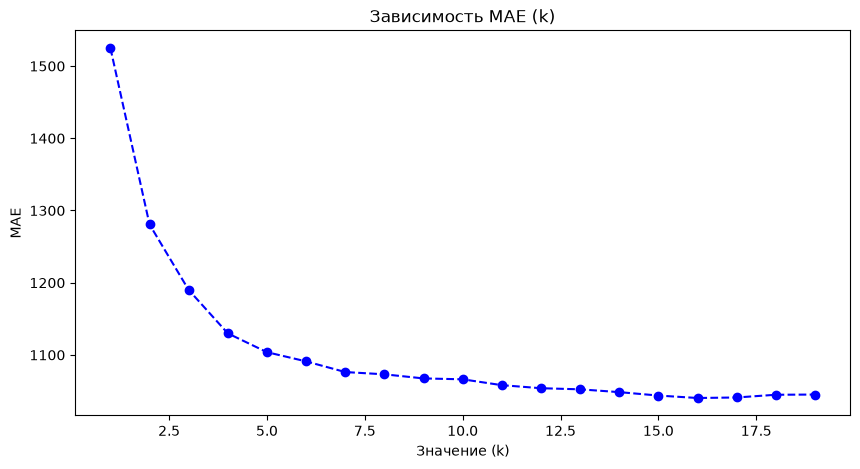

In [25]:
errors=[]
k_range=range(1, 20)

for k in k_range:
    knn=KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred=knn.predict(X_test)
    errors.append(mean_absolute_error(y_test, y_pred))

plt.figure(figsize=(10,5))
plt.plot(k_range, errors, marker="o", linestyle="dashed", color="blue")
plt.title("Зависимость MAE (k)")
plt.xlabel("Значение (k)")
plt.ylabel("MAE")
plt.show()

Вывод: Продемонстрирован процесс подбора гиперпараметра $k$ для алгоритма k-ближайших соседей с целью минимизации ошибки прогнозирования. 

# Исследование метрик расстояния Минковского

In [26]:
best_k=5

# Обучаем модель с Евклидовой метрикой (p=2)
knn_euclidean=KNeighborsRegressor(n_neighbors=best_k, p=2)
knn_euclidean.fit(X_train, y_train)
y_pred_euc=knn_euclidean.predict(X_test)

# Обучаем модель с Манхэттенской метрикой (p=1)
knn_manhattan=KNeighborsRegressor(n_neighbors=best_k, p=1)
knn_manhattan.fit(X_train, y_train)
y_pred_man=knn_manhattan.predict(X_test)

print("=== Сравнение метрик расстояния ===")
print(f"Евклидово расстояние (p=2): MAE = ${mean_absolute_error(y_test, y_pred_euc):,.2f} | R2={r2_score(y_test, y_pred_euc):,.2f}")
print(f"Манхэттенское расстояние (p=1): MAE = ${mean_absolute_error(y_test, y_pred_man):,.2f} | R2={r2_score(y_test, y_pred_man):,.2f}")

=== Сравнение метрик расстояния ===
Евклидово расстояние (p=2): MAE = $1,103.79 | R2=0.75
Манхэттенское расстояние (p=1): MAE = $1,156.94 | R2=0.73


Вывод: Евклидово расстояние продемонстрировало более высокую точность ($R^2 = 0.75$, MAE = $1,103.79) по сравнению с манхэттенской метрикой ($R^2 = 0.73$, MAE = $1,156.94) для данной задачи. 

# Регрессия Надарая-Ватсона

In [27]:
gamma_values=np.logspace(-2,1,30)

best_gamma=0
best_r2= -float("inf")
best_mae= float("inf")

for g in gamma_values:
    weights=rbf_kernel(X_test, X_train, gamma=g)
    weights_noramalized=weights/weights.sum(axis=1, keepdims=True)

    y_pred_nw=np.dot(weights_noramalized, y_train.values)

    r2=r2_score(y_test, y_pred_nw)
    mae=mean_absolute_error(y_test, y_pred_nw)

    if r2>best_r2:
        best_r2=r2
        best_mae=mae
        best_gamma=g

print("=== Итоги оптимизации ядерной регрессии===")
print(f"Оптимальный gamma: {best_gamma:.2f}")
print(f"Лучшее R2: {best_r2:.2f}")
print(f"Лучшее MAE: ${best_mae:.2f}")

=== Итоги оптимизации ядерной регрессии===
Оптимальный gamma: 1.49
Лучшее R2: 0.77
Лучшее MAE: $1063.84


Вывод: Подбор оптимального коэффициента $\gamma = 1.49$ позволил достичь наилучших показателей качества среди рассмотренных подходов ($R^2 = 0.77$, MAE = $1,063.84). 

# Визуализация

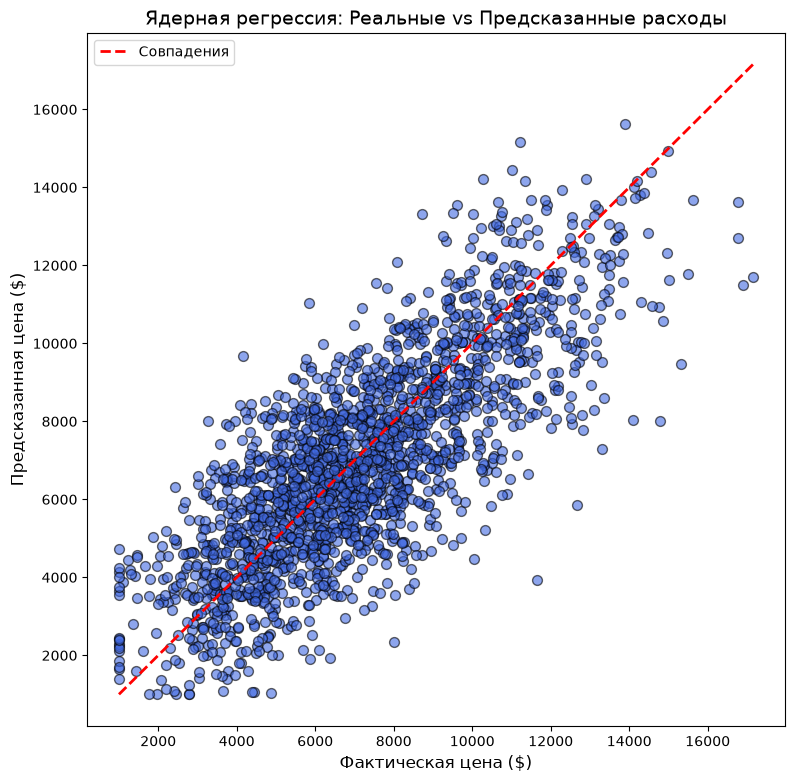

In [32]:
plt.figure(figsize=(9,9))

plt.scatter(y_test, y_pred_nw, alpha=0.6, color="royalblue", edgecolors="k", s=50)

max_val=max(y_test.max(), y_pred_nw.max())
min_val=min(y_test.min(), y_pred_nw.min())

plt.plot(
    [min_val, max_val], [min_val, max_val], "r--", lw=2, label="Совпадения"
)

plt.title("Ядерная регрессия: Реальные vs Предсказанные расходы", fontsize=14)
plt.xlabel("Фактическая цена ($)", fontsize=12)
plt.ylabel("Предсказанная цена ($)", fontsize=12)
plt.legend()
plt.show()

Вывод: Визуальные компоненты дополняют числовые метрики, позволяя наглядно оценить характер распределения ошибок и качество аппроксимации.